In [2]:
from matplotlib.pyplot import barh
from nbformat.v1 import upgrade
from statsmodels.compat.pandas import to_numpy

from Client import client
import pandas as pd

matches = pd.DataFrame()
objectives = pd.DataFrame()
players = pd.DataFrame()
stats = pd.DataFrame()
items = pd.DataFrame()

cli = client(df_matches=matches, df_objectives=objectives, df_players=players, df_stats=stats, df_items=items)

In [3]:
items = cli.df_items

In [4]:
apollo_items = items[items["hero_id"] == 77]

In [5]:
player = apollo_items[apollo_items['account_id'] == 1081290053]

In [6]:
player['match_id'].value_counts()

Series([], Name: count, dtype: Int64)

In [7]:
player

,match_id,account_id,hero_id,game_time_s,item_name,item_id,upgrade_id,sold_time_s,flags,imbued_ability_id,upgrade_info,net_worth


In [8]:
filter_items = player = apollo_items['match_id'].drop_duplicates()

all_purchases = []

for id in filter_items:
    unique_items = apollo_items[
        apollo_items['match_id'] == id
    ].drop_duplicates(subset='item_id')

    all_purchases.append(unique_items[['item_name', 'game_time_s']])

purchases = pd.concat(all_purchases, ignore_index=True)
item_counts = purchases['item_name'].value_counts()
item_avg_time = purchases.groupby('item_name')['game_time_s'].mean()


item_summary = pd.DataFrame({'item_counts': item_counts, 'item_avg_time': item_avg_time})
item_summary = item_summary.reset_index().rename(columns={'index': 'item_name'})

item_summary = item_summary.sort_values('item_counts', ascending=False)

In [9]:
item_summary

,item_name,item_counts,item_avg_time
59,Mystic Burst,178,203.477528
45,Improved Spirit,174,636.293103
103,Tankbuster,162,1399.648148
29,Extra Spirit,161,302.571429
60,Mystic Expansion,151,405.463576
...,...,...,...
94,Split Shot,1,632.0
104,Titanic Magazine,1,372.0
102,Swift Striker,1,631.0
109,Vampiric Burst,1,1547.0


<BarContainer object of 12 artists>

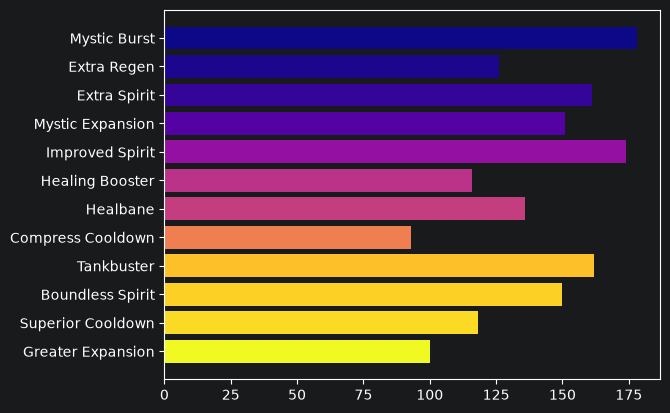

In [10]:
import matplotlib.pyplot as plt
top_20_items = item_summary.sort_values('item_counts', ascending=False).head(12)
top_20_items = top_20_items.sort_values('item_avg_time', ascending=False)

colors = top_20_items['item_avg_time'].to_numpy()
cmap = plt.get_cmap('plasma')
norm = plt.Normalize(top_20_items['item_avg_time'].min(), top_20_items['item_avg_time'].max())
colors = cmap(norm(top_20_items['item_avg_time'].to_numpy()))

plt.barh(top_20_items['item_name'], top_20_items['item_counts'],color=colors)

In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression

